# RAG básico passo à passo

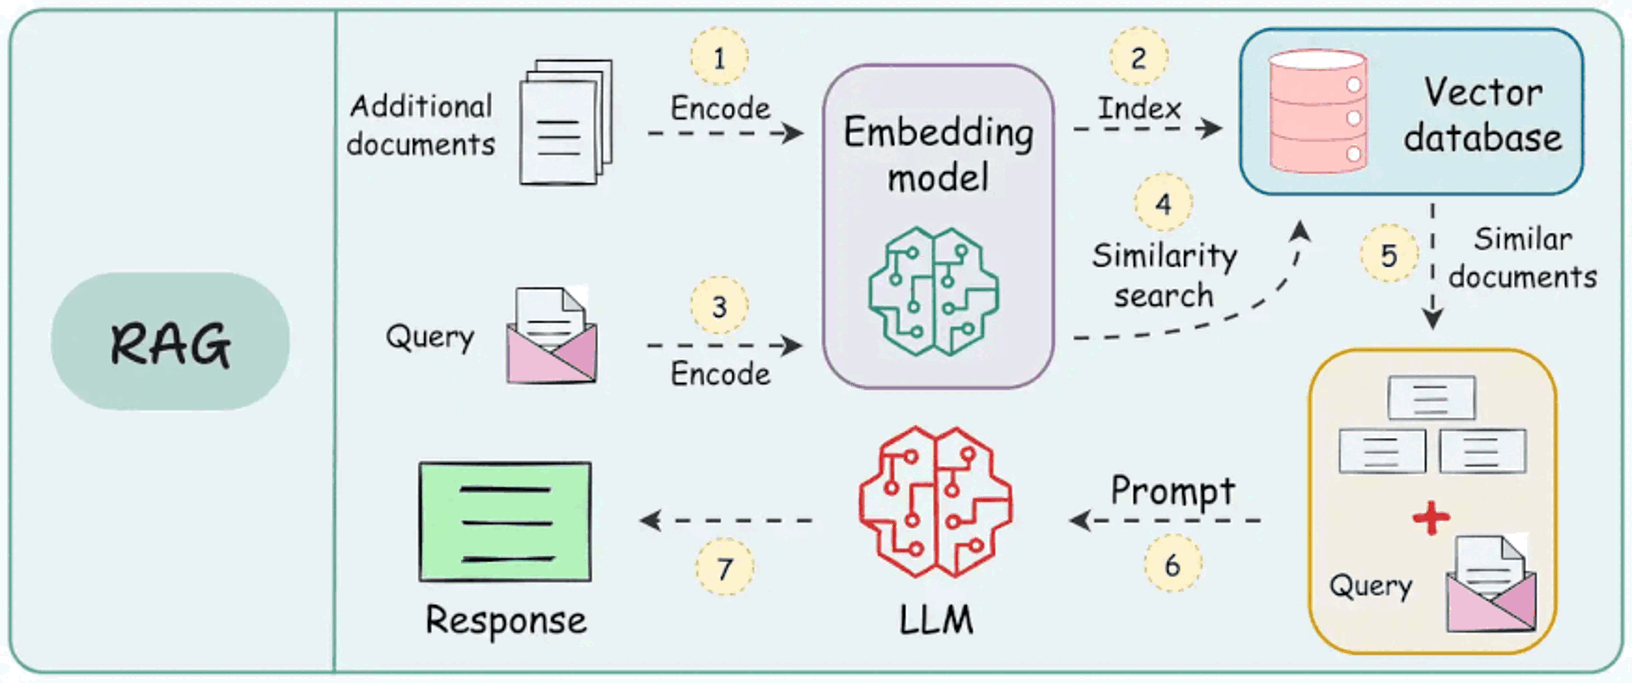

## 0. Instalar dependências

In [ ]:
%pip install -qU langchain langchain-openai langchain-community pypdf

In [ ]:
from dotenv import load_dotenv
load_dotenv()

In [ ]:
import os
os.environ.get("LANGSMITH_API_KEY")

In [ ]:
openai_api_key = os.getenv("OPENAI_API_KEY")

import getpass
if not openai_api_key:
    openai_api_key = getpass.getpass()

In [ ]:
openai_api_key

## 1. Baixar documentos e vetorizar com Embeddings

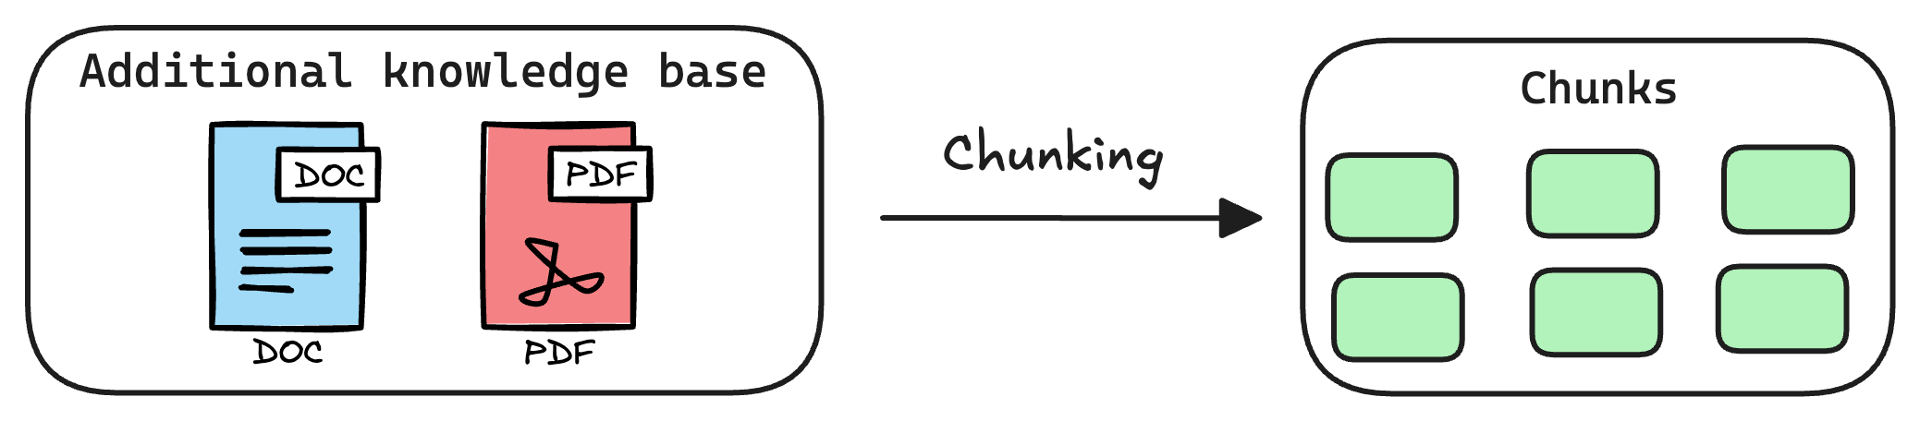

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

documento = PyPDFLoader("documentos/GTB_gold_Nov23.pdf").load()

In [ ]:
documento

In [ ]:
%pip install bs4

In [ ]:
from langchain_community.document_loaders import WebBaseLoader

url =  "https://forbes.com.br/forbes-tech/2025/08/o-que-explica-o-fracasso-do-chatgpt-5-e-como-a-openai-vai-reagir/"

noticia = WebBaseLoader(web_path=url).load()
noticia

In [ ]:
!pip install -q unstructured "unstructured[pdf]"

In [ ]:
from langchain_community.document_loaders import DirectoryLoader

pdfs = DirectoryLoader("documentos", glob="*.pdf").load()

In [ ]:
len(pdfs)

In [ ]:
pdfs[2]

In [ ]:
from langchain_community.document_loaders.merge import MergedDataLoader
from langchain_community.document_loaders import TextLoader

all_loaders = MergedDataLoader(loaders=[WebBaseLoader(web_path=url), TextLoader("documentos/GTB_gold_Nov23.txt", encoding="utf-8")])

all_docs = all_loaders.load()

In [ ]:
len(all_docs)

In [ ]:
all_docs[0]

In [ ]:
%pip install -qU langchain-community beautifulsoup4 lxml

In [ ]:
from langchain_community.document_loaders import RecursiveUrlLoader

loader = RecursiveUrlLoader("https://python.langchain.com/api_reference/")

lc_docs = loader.load()

In [ ]:
len(lc_docs)

In [ ]:
lc_docs[60]

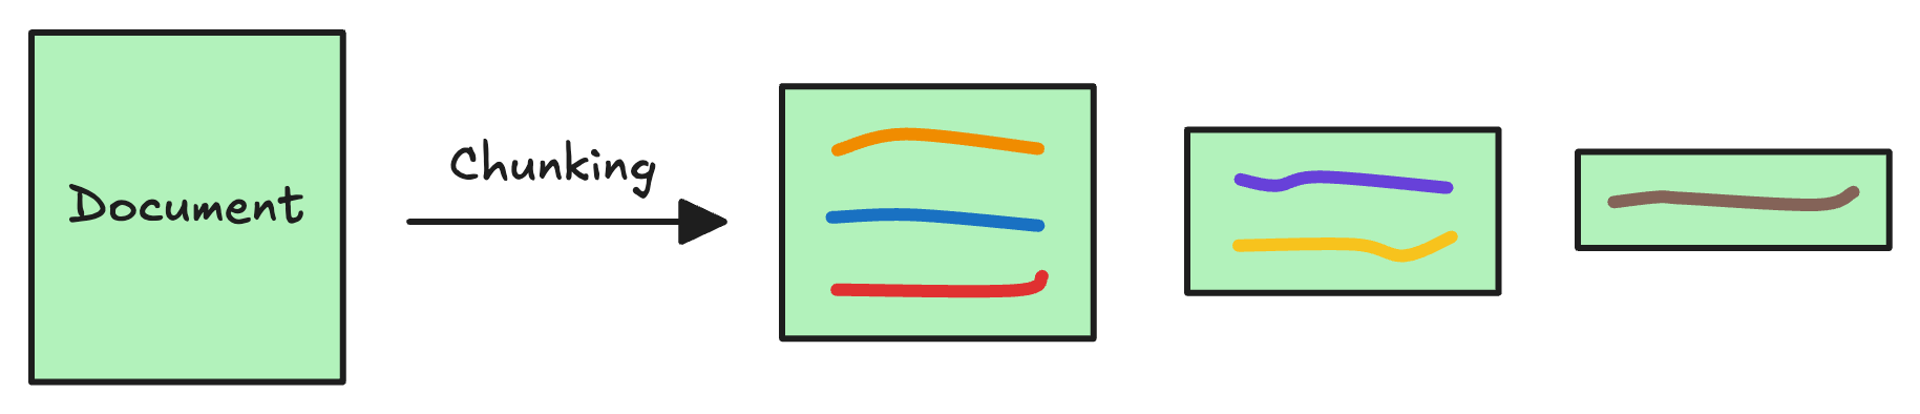

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100
)

pedacos = splitter.split_documents(pdfs)

In [ ]:
len(pedacos)

In [ ]:
!pip install --upgrade --quiet langchain-text-splitters tiktoken

In [ ]:
from langchain_text_splitters import CharacterTextSplitter

token_splitter = CharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base", chunk_size=512, chunk_overlap=50)

token_pedacos = token_splitter.split_documents(pdfs)

In [ ]:
len(token_pedacos)

In [ ]:
token_pedacos[33]

In [ ]:
pedacos[200]

In [ ]:
!pip install transformers

In [ ]:
from transformers import AutoTokenizer, AutoModel

emb_tokenizer = AutoTokenizer.from_pretrained('intfloat/multilingual-e5-small')
emb_model = AutoModel.from_pretrained('intfloat/multilingual-e5-small')

In [ ]:
hf_splitter = CharacterTextSplitter.from_huggingface_tokenizer(
    tokenizer=emb_tokenizer,
    chunk_size=512, chunk_overlap=50
)

hf_pedacos = hf_splitter.split_documents(pdfs)

In [ ]:
len(hf_pedacos)

In [ ]:
hf_pedacos[30]

In [ ]:
!pip install -qU langchain_experimental

In [ ]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_openai.embeddings import OpenAIEmbeddings

semantic_openai_splitter = SemanticChunker(OpenAIEmbeddings())


In [ ]:
semantic_openai_pedacos = semantic_openai_splitter.split_documents(pdfs)

In [ ]:
len(semantic_openai_pedacos)

In [ ]:
semantic_openai_pedacos[12]

In [ ]:
!pip install -qU langchain_huggingface sentence_transformers

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings

hf_emb_model = HuggingFaceEmbeddings(model_name="intfloat/multilingual-e5-small")

In [ ]:
semantic_hf_splitter = SemanticChunker(hf_emb_model)
semantic_hf_pedacos = semantic_hf_splitter.split_documents(pdfs)

In [ ]:
len(semantic_hf_pedacos)

In [ ]:
semantic_hf_pedacos[22]

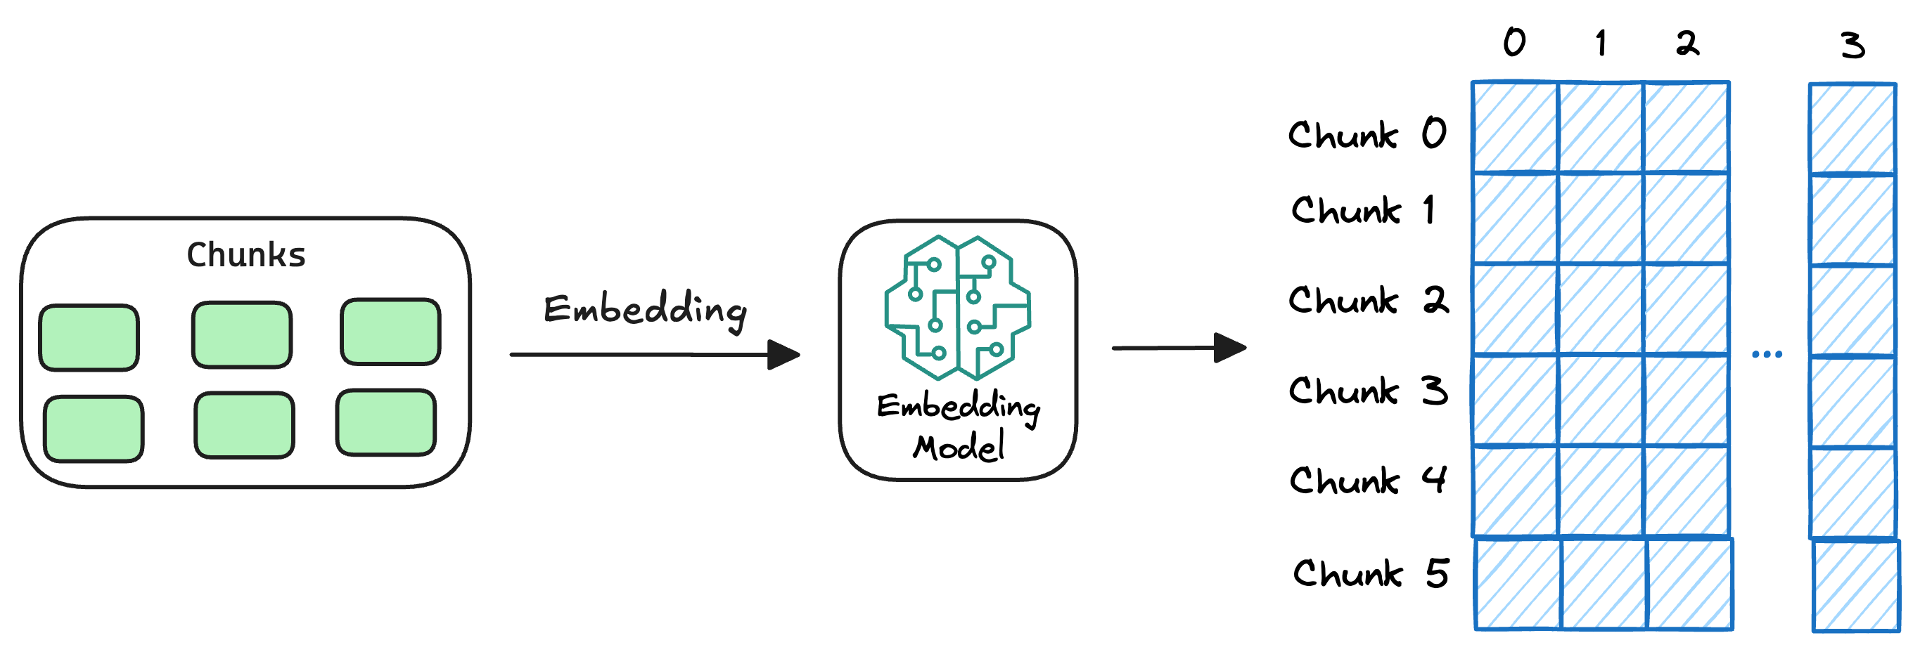

In [ ]:
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings()

In [ ]:
embeddings_model.model

In [ ]:
pedacos[0].page_content

In [ ]:
embeddings_model.embed_query(pedacos[0].page_content)

## 2. Indexar documentos no bando de dados vetorial

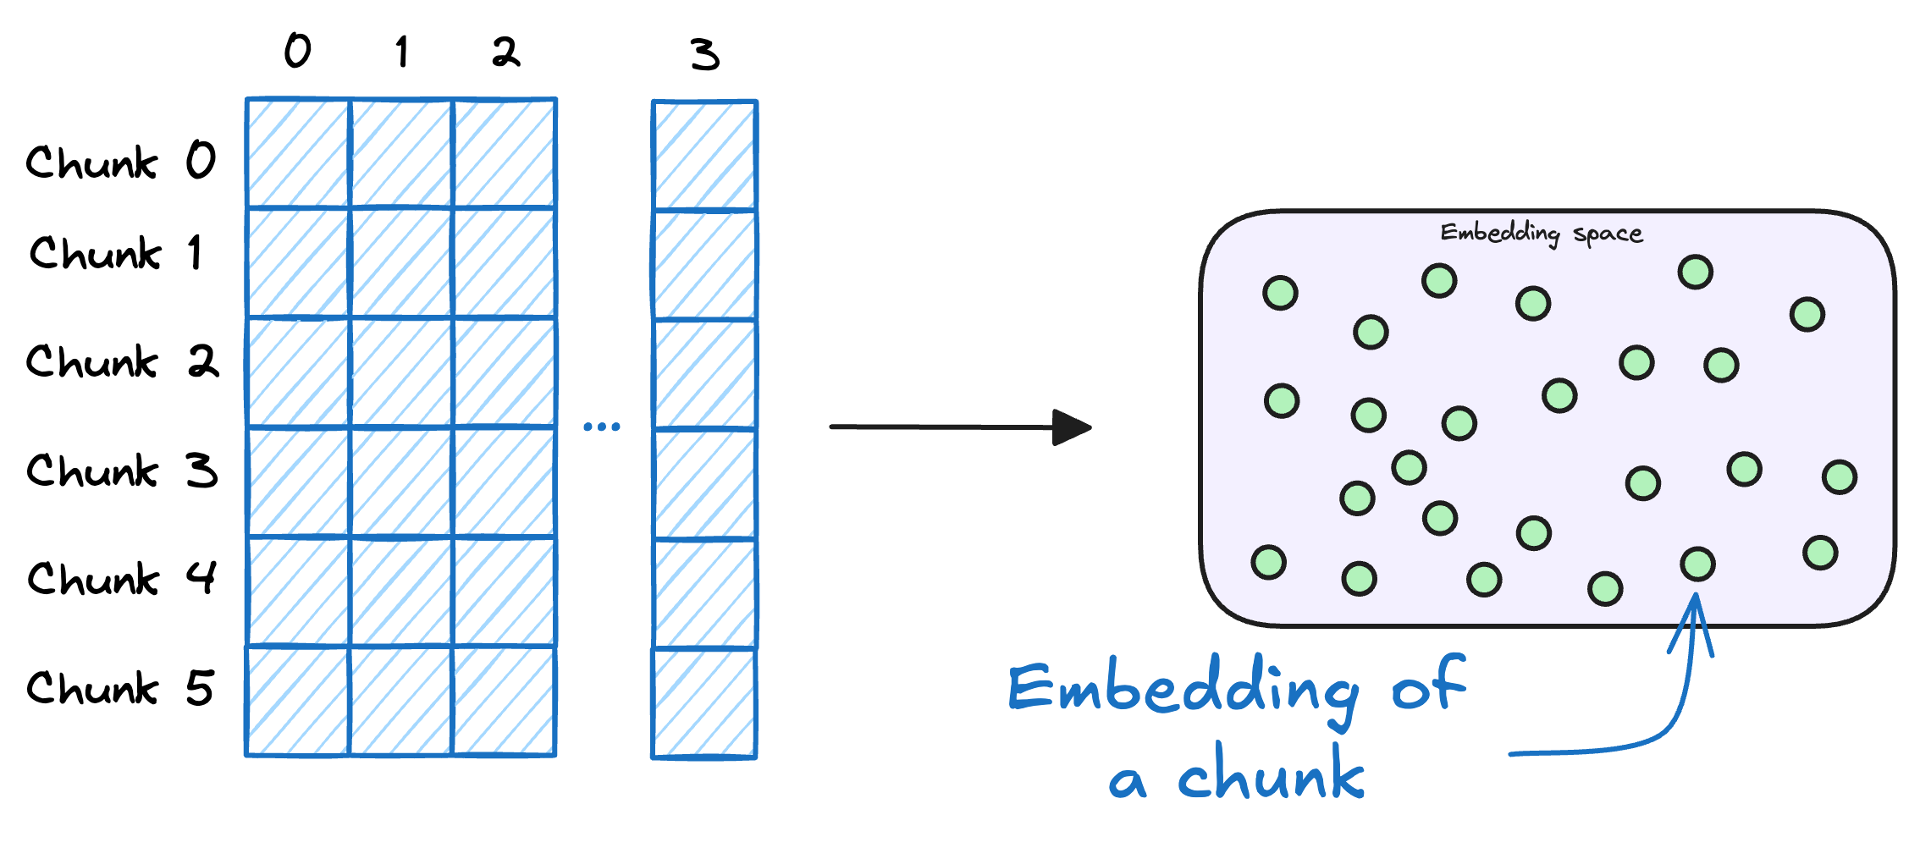

In [ ]:
from langchain_community.vectorstores import InMemoryVectorStore

vectorstore = InMemoryVectorStore.from_documents(
    documents=semantic_hf_pedacos, embedding=hf_emb_model
)

In [ ]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

In [ ]:
retriever.invoke("Sala VIP")

In [ ]:
!pip install -qU faiss-cpu

In [ ]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(
    documents=semantic_hf_pedacos, embedding=hf_emb_model
)

retriever = vectorstore.as_retriever()

retriever.invoke("Sala VIP")

In [ ]:
!pip install -qU langchain-pinecone

In [ ]:
from langchain_pinecone import PineconeVectorStore

pc_vector_store2 = PineconeVectorStore(
    host="https://rag-langchain-akz9rnm.svc.aped-4627-b74a.pinecone.io",
    pinecone_api_key="pcsk_SHKfv_96t1V5Hyj6gSRF2iLf8F4oFJomFDWCWiuZw1ymVGc9kwn67W3MqufgvL89kqHWd",
    embedding=hf_emb_model)


In [ ]:
pc_vector_store2.add_documents(semantic_hf_pedacos)

In [ ]:
pc_vector_store2.similarity_search_with_score("Seguro viagem", k=2)

## 3. Receber consulta do usuário e fazer Embedding

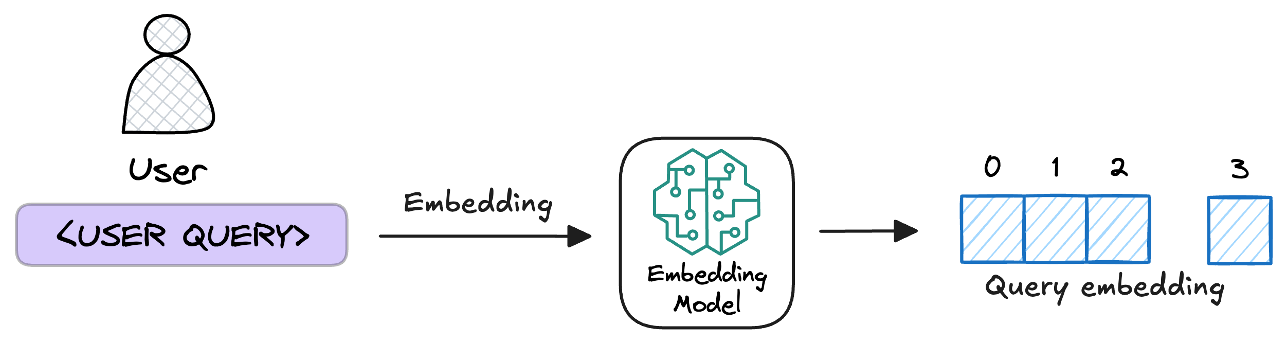

In [ ]:
query = "Como devo proceder caso tenha um cartão Gold roubado?"

query_embed = embeddings_model.embed_query(query)
query_embed

## 4. Buscar Embeddings da consulta no banco vetorial

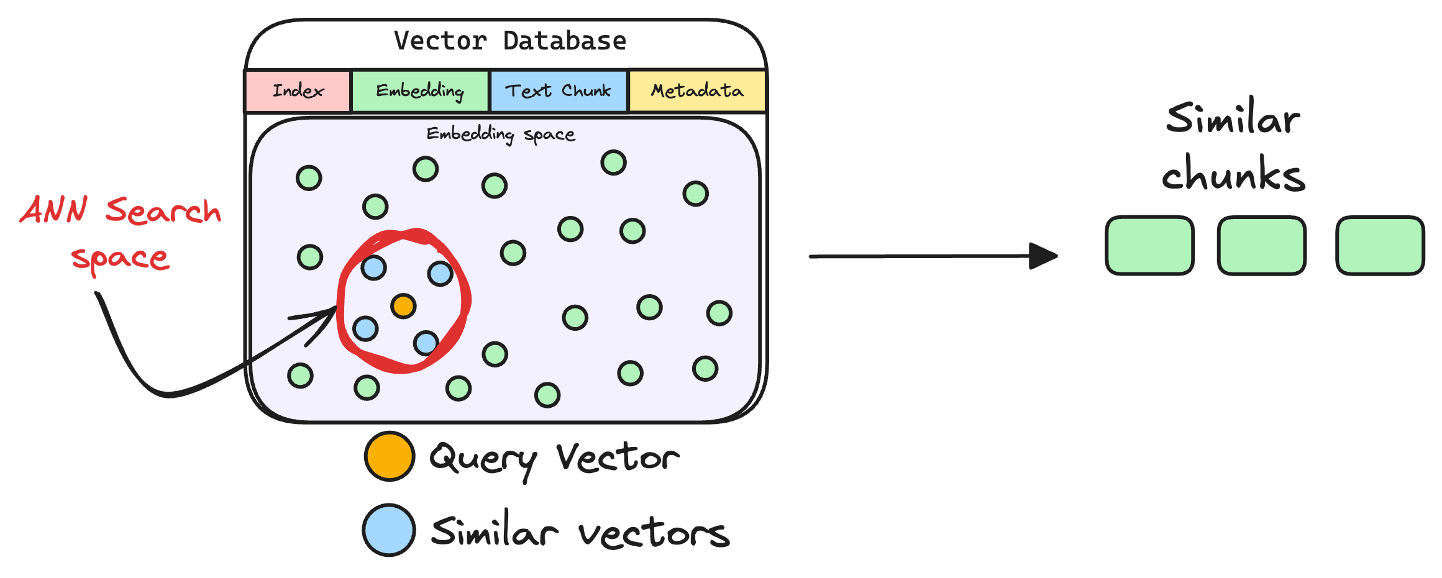

In [ ]:
similar_chunks = retriever.invoke(query)
similar_chunks

## Question transformations - Rewrite-Retrieve-Read

![image.png](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*wOQsUx-_JRs4zhp7u77Tsw.png)

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
llm = ChatOpenAI(model="gpt-4.1-nano", openai_api_key=openai_api_key)

rewriter_prompt_template = """
Gere consulta de pesquisa para o banco de dados de vetores (Vector DB) a partir de uma pergunta do usuário,
permitindo uma resposta mais precisa por meio da busca semântica.
Basta retornar a consulta revisada do Vector DB, entre aspas.

Pergunta do usuário: {user_question}
Consulta revisada do Vector DB:
"""

rewriter_prompt = PromptTemplate.from_template(rewriter_prompt_template)

rewriter_chain = rewriter_prompt | llm | StrOutputParser()

print(query)
rewriter_chain.invoke(query)

In [ ]:
retriever.invoke(query)[0]

In [ ]:
retriever.invoke(rewriter_chain.invoke(query))[0]

## Generating multiple queries

![](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*z1EuCfvPHtmISs0dldU1Tw.png)

In [ ]:
multi_query_prompt_template = """Você é um assistente de modelo de linguagem de IA. Sua tarefa é gerar cinco
versões diferentes da pergunta do usuário para recuperar documentos relevantes de um banco de dados vetorial.
Ao gerar múltiplas perspectivas sobre a pergunta do usuário, seu objetivo é ajudar
o usuário a superar algumas das limitações da busca por similaridade baseada em distância.
Forneça estas perguntas alternativas separadas por quebras de linha.
Pergunta original: {question}"""

multi_query_prompt = PromptTemplate.from_template(multi_query_prompt_template)

from langchain_core.output_parsers import CommaSeparatedListOutputParser

multi_query_chain = multi_query_prompt | llm | CommaSeparatedListOutputParser()

print(query)
multi_query_chain.invoke(query)

In [ ]:
from langchain.retrievers.multi_query import MultiQueryRetriever

multi_query_retriever = MultiQueryRetriever(
    retriever=retriever, llm_chain=multi_query_chain, 
)  

multi_query_retriever.invoke(query)

## Question transformations — Step-Back Question

![](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*NK2G6readqx4lxaw3G0M2w.png)

In [ ]:
step_back_prompt_template = """
Crie uma pergunta menos específica (também conhecida como pergunta passo-a-passo) para a seguinte pergunta detalhada, 
para que um contexto mais amplo possa ser recuperado.
Pergunta detalhada: {detailed_question}
Pergunta passo a passo:
"""

step_back_prompt = PromptTemplate.from_template(step_back_prompt_template)

step_back_question_gen_chain = step_back_prompt | llm | StrOutputParser() | retriever

In [ ]:
step_back_question_gen_chain.invoke(query)

## Hypothetical Document Embeddings (HyDE)

![](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*akOv9WTwCEdnTgM5VMIi9A.png)

In [ ]:
hyde_prompt_template = """
Escreva uma frase que possa responder à pergunta apresentada. Não adicione mais nada.
Pergunta: {query}
Frase:
"""

hyde_prompt = PromptTemplate.from_template(hyde_prompt_template)
# Next, build the HyDE chain:
hyde_chain = hyde_prompt | llm | StrOutputParser()


In [ ]:
hyde_chain.invoke(query)

In [ ]:
retriever.invoke(hyde_chain.invoke(query))

## 5. Resgatar os documentos similares do banco

In [ ]:
similar_texts = [ pedaco.page_content for pedaco in similar_chunks ]
similar_texts

## 6. Aumentar o prompt com consulta e documentos

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages(
    [ 
        ("system", "Responda usando exclusivamente os conteúdo fornecido. \n\nContexto:\n{contexto}"),
        ("human", "{query}")
    ]
)

## 7. Gerar a Resposta

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

modelo = ChatOpenAI(
    model="gpt-4.1-nano",
    temperature=0.2,
    api_key=openai_api_key
)

In [ ]:
modelo.invoke(query).content

In [ ]:
cadeia = prompt | modelo | StrOutputParser()

query = "Qual número ligar caso meu cartão seja roubado?"

trechos = pc_vector_store2.as_retriever(search_kargs={"k": 2}).invoke(query)

contexto = "\n\n".join(trecho.page_content for trecho in trechos)

cadeia.invoke({"query": query, "contexto": contexto})

In [ ]:
from langchain_core.runnables import RunnablePassthrough

hyde_rag_chain = (
    {
        "contexto": {"query": RunnablePassthrough()} | hyde_chain | retriever ,
        "query": RunnablePassthrough(),#B
    }
    | cadeia
)

In [ ]:
hyde_rag_chain.invoke(query)

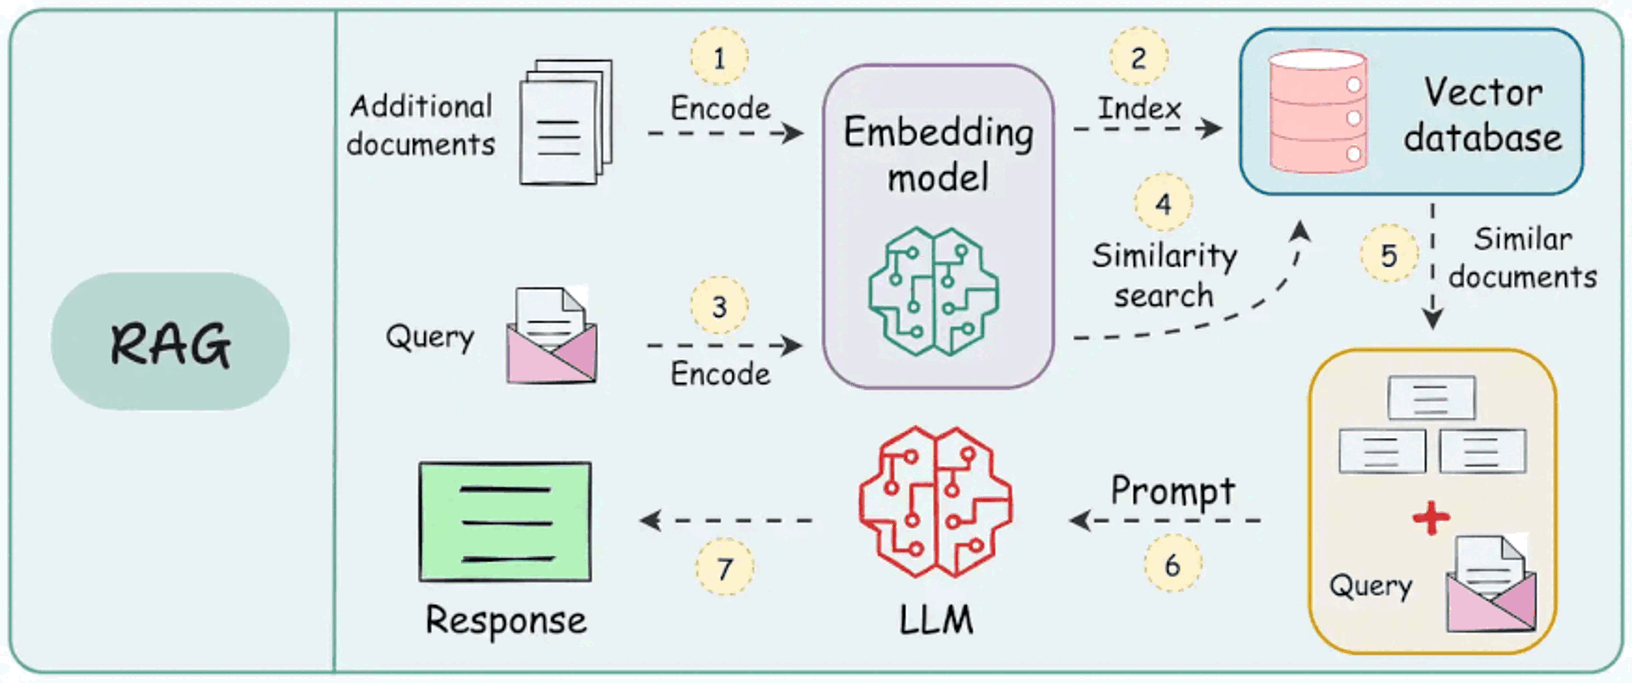

# create_stuff_documents_chain

In [ ]:
# pip install -U langchain langchain-community

from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain.chains import create_retrieval_chain

rag_prompt = ChatPromptTemplate.from_messages(
    [ 
        ("system", "Responda usando exclusivamente os conteúdo fornecido. \n\nContexto:\n{context}"),
        ("human", "{query}")
    ]
)

combine_docs_chain = create_stuff_documents_chain(
    modelo, rag_prompt
)
hyde_chain_retriever = hyde_chain | retriever

retrieval_chain = create_retrieval_chain(hyde_chain_retriever, combine_docs_chain)

retrieval_chain.invoke({"query": query})

In [ ]:
!pip install -qU langchain-ollama

In [ ]:
from langchain_ollama.llms import OllamaLLM

ollama_gemma3 = OllamaLLM(model="gemma3:4b")

ollama_gemma3.invoke(query)


In [ ]:
combine_docs_chain = create_stuff_documents_chain(
    ollama_gemma3, rag_prompt
)
hyde_chain_retriever = hyde_chain | retriever

retrieval_chain = create_retrieval_chain(hyde_chain_retriever, combine_docs_chain)

retrieval_chain.invoke({"query": query})